In [ ]:
from Nanodiffraction_Script import load_scan, get_image

import time
import h5py, hdf5plugin
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.patches as patches


import tkinter as tk
from tkinter import filedialog

import multiprocessing
from concurrent.futures import ThreadPoolExecutor

# %matplotlib inline

In [2]:
# root = tk.Tk()
# root.withdraw()
# root.attributes('-topmost', True)
# file_path = filedialog.askopenfilename(
#     title="Select MDA file",
#     initialdir='/Users/smith.scott/Documents/Postdoc/Data/S26_20260211/data/mda',
#     filetypes=[("MDA files", "*.mda"), ("All files", "*.*")]
# )
# root.destroy()

# if file_path:
#     print(f"Selected file: {file_path}")
#     result = load_scan(file_path)
#     print(f"Loaded {result.ndim}-D scan with {len(result.detector_names)} detectors")
#     print(f"Image index range: {result.image_index_min} — {result.image_index_max}")
#     if result.h5 is not None:
#         print(f"HDF5 dataset shape: {result.h5['entry/data/data'].shape}")
#         result.h5.close()
# else:
#     print("No file selected.")


In [3]:
ScanNum = 82

file_path = f'/Users/smith.scott/Documents/Postdoc/Data/S26_20260211/data/mda/26idbSOFT_{ScanNum:04}.mda'
print(file_path)

/Users/smith.scott/Documents/Postdoc/Data/S26_20260211/data/mda/26idbSOFT_0082.mda


In [4]:
mda = load_scan(file_path)
print(mda.ndim)
img = get_image(mda, index=0)

Scan 82 loaded: 100 points in x, 101 points in y
2


In [ ]:
#Preload Data to memory

t0 = time.time()
print("Loading all frames into RAM (slow once, fast forever)...")
with h5py.File(mda.h5.filename, 'r') as f:
    all_frames = f['/entry/data/data'][()]  # shape: (n_frames, height, width)
all_frames[all_frames > 2**31] = 0          # hot pixel masking
print(f"Load time: {time.time()-t0:.1f}s")

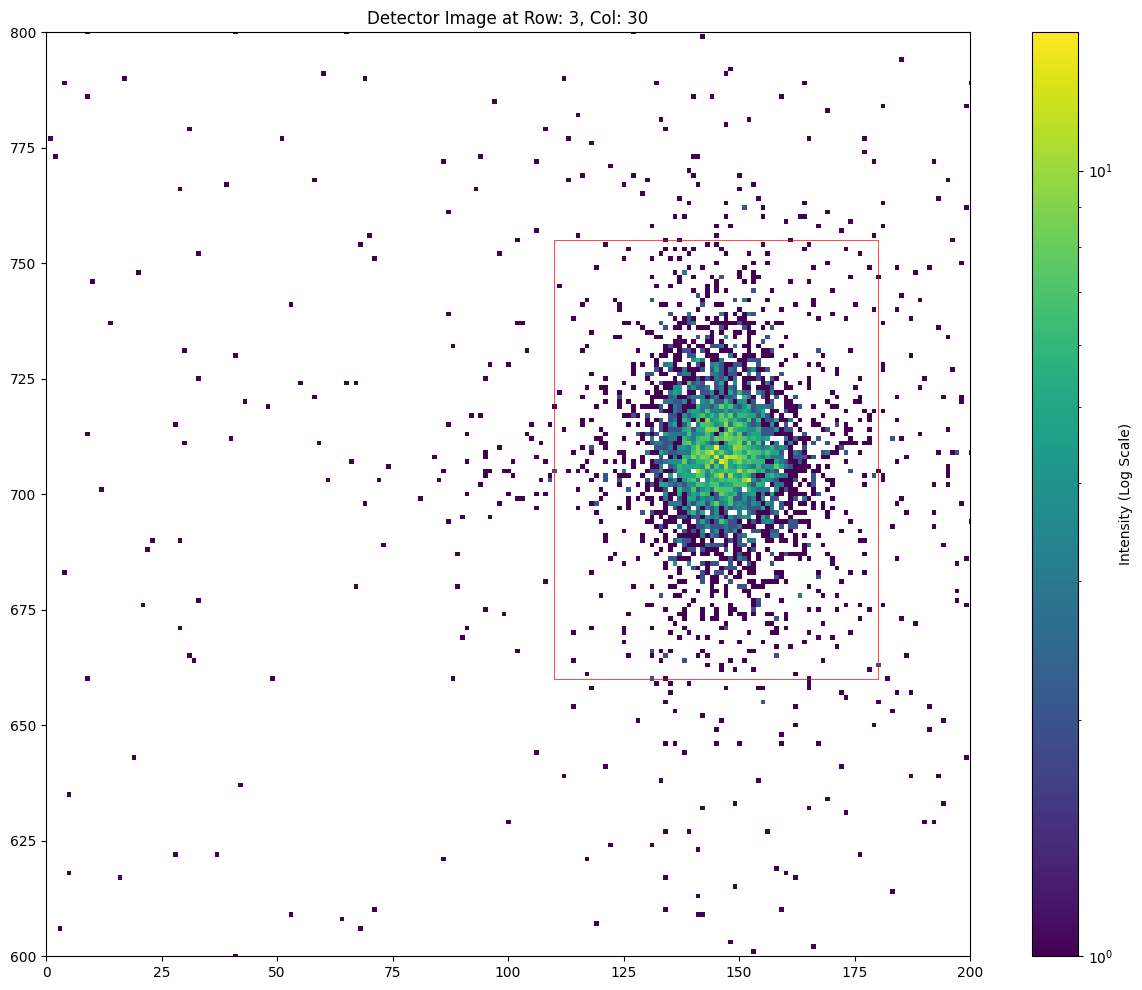

In [5]:
mda.ncol
mda.nrow

# Desired row and col for image
i = 3
j = 30

xmin = 0
xmax = 200
ymin = 600
ymax = 800

lindex = (i * mda.ncol) + j

img = get_image(mda, index=lindex)

#Create plot and show ROI box
fig, ax = plt.subplots(figsize=(16, 12))
im = ax.imshow(img, norm=LogNorm(), cmap='viridis')
fig.colorbar(im, ax=ax, label='Intensity (Log Scale)')
ax.set_title(f"Detector Image at Row: {i}, Col: {j}")
ax.set_xlim(xmin,xmax)
ax.set_ylim(ymin,ymax)

# Define ROI bo0undaries (xmin, ymin, width, height)
roi_xmin = 110
roi_ymin = 660
roi_width = 70
roi_height = 95

# Create a Rectangle patch
roi_rect = patches.Rectangle(
    (roi_xmin, roi_ymin), roi_width, roi_height, 
    linewidth=0.5, edgecolor='r', facecolor='none'
)

# Add the patch to the Axes
ax.add_patch(roi_rect)

plt.show()

 # ROI Loading and Integration

In [ ]:
# Now ROI queries are near-instant
ymin, ymax = roi_ymin, roi_ymin + roi_height
xmin, xmax = roi_xmin, roi_xmin + roi_width

t1 = time.time()
intensity_1d = all_frames[:, ymin:ymax+1, xmin:xmax+1].sum(axis=(1,2))
intensity_2d = intensity_1d[:mda.nrow * mda.ncol].reshape(mda.nrow, mda.ncol)
intensity_2d[1::2, :] = intensity_2d[1::2, ::-1] #reshape to account for snake scan ()
print(f"ROI integration: {time.time()-t1:.3f}s")


Extracting ROI: Y[660:756], X[110:181]
Data extraction and integration finished in 53.65 seconds!


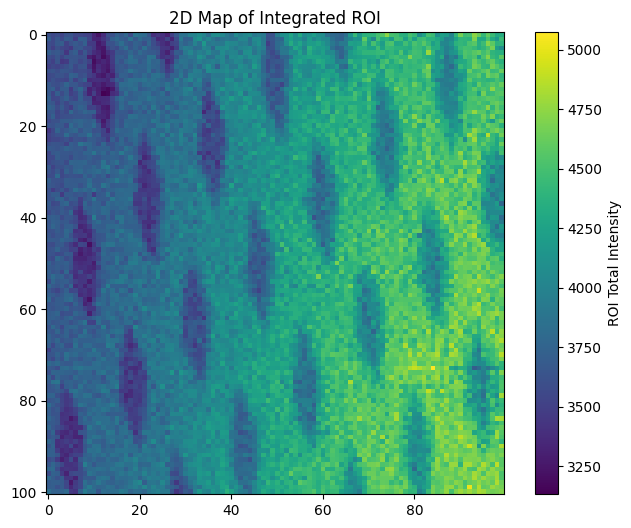

In [8]:
# 5. Plot the resulting 2D scan map
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(intensity_2d, cmap='viridis')
fig.colorbar(im, ax=ax, label='ROI Total Intensity')
ax.set_title("2D Map of Integrated ROI")
plt.show()

In [7]:
result.h5.close()  # if Eiger

AttributeError: 'numpy.ndarray' object has no attribute 'h5'